In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import warnings
warnings.filterwarnings('ignore',category = FutureWarning)
import seaborn as sns

In [5]:
sales_data = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\sales_data.csv")


In [6]:
sales_data.head()

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,20160109,1,13927.0,934,18680
1,20160109,3,10289.0,1592,28646
2,20160109,4,357.0,22,440
3,20160109,6,23113.0,2027,81088
4,20160109,7,23177.0,3231,58164


In [7]:
sales_data.tail()

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
4526177,20181027,47536,8.0,2,3
4526178,20181027,47539,391.0,39,68
4526179,20181027,47543,105.0,59,48
4526180,20181027,47544,3720.0,1246,4361
4526181,20181027,47545,1729.0,2016,378


In [8]:
sales_data.shape

(4526182, 5)

In [9]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 5 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   system_calendar_key_N  int64  
 1   product_id             int64  
 2   sales_dollars_value    float64
 3   sales_units_value      int64  
 4   sales_lbs_value        int64  
dtypes: float64(1), int64(4)
memory usage: 172.7 MB


In [10]:
sales_data.isnull().sum()

system_calendar_key_N    0
product_id               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
dtype: int64

In [11]:
sales_data.describe().T

,count,mean,std,min,25%,50%,75%,max
system_calendar_key_N,4526182.0,2.017505e+07,10735.371398,20160109.0,20161231.0,20171209.0,20181103.0,20191005.0
product_id,4526182.0,2.885857e+04,15312.536560,1.0,15069.0,29981.0,41513.0,57317.0
sales_dollars_value,4526182.0,2.159454e+04,78180.565626,0.0,523.0,2655.0,11765.0,4395964.0
sales_units_value,4526182.0,5.160053e+03,26853.407825,1.0,80.0,403.0,1807.0,873998.0
sales_lbs_value,4526182.0,1.715339e+04,127340.124381,0.0,86.0,611.0,3770.0,11003100.0


In [12]:
sales_data.describe()

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
count,4.526182e+06,4.526182e+06,4.526182e+06,4.526182e+06,4.526182e+06
mean,2.017505e+07,2.885857e+04,2.159454e+04,5.160053e+03,1.715339e+04
std,1.073537e+04,1.531254e+04,7.818057e+04,2.685341e+04,1.273401e+05
min,2.016011e+07,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2.016123e+07,1.506900e+04,5.230000e+02,8.000000e+01,8.600000e+01
50%,2.017121e+07,2.998100e+04,2.655000e+03,4.030000e+02,6.110000e+02
75%,2.018110e+07,4.151300e+04,1.176500e+04,1.807000e+03,3.770000e+03
max,2.019100e+07,5.731700e+04,4.395964e+06,8.739980e+05,1.100310e+07


In [13]:
from datetime import datetime

In [14]:
#20181027 -- format='%Y%m%d'

#27012018 -- format='%d%m%Y'

#27-01-2018 -- format='%d-%m-%Y'

sales_data['system_calendar_key_N'] = pd.to_datetime(sales_data['system_calendar_key_N'],format = '%Y%m%d',errors = 'ignore')

In [15]:
print(sales_data.dtypes)

system_calendar_key_N    datetime64[ns]
product_id                        int64
sales_dollars_value             float64
sales_units_value                 int64
sales_lbs_value                   int64
dtype: object


In [16]:
sales_data.head()

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646
2,2016-01-09,4,357.0,22,440
3,2016-01-09,6,23113.0,2027,81088
4,2016-01-09,7,23177.0,3231,58164


In [17]:
google_search_data = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\google_search_data.csv")

In [18]:
google_search_data.head()

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,05-01-2014,google,349,916,1,2014
1,06-01-2014,google,349,916,2,2014
2,07-01-2014,google,697,916,2,2014
3,10-01-2014,google,349,916,2,2014
4,20-01-2014,google,697,916,4,2014


In [19]:
google_search_data.tail()

,date,platform,searchVolume,Claim_ID,week_number,year_new
181560,05-09-2019,walmart,125,980,36,2019
181561,22-09-2019,walmart,84,980,38,2019
181562,26-09-2019,walmart,42,980,39,2019
181563,15-07-2019,walmart,42,622,29,2019
181564,02-09-2019,walmart,42,689,36,2019


In [20]:
google_search_data.shape

(181565, 6)

In [21]:
google_search_data['platform'].value_counts()

platform
google     138115
amazon      23828
chewy       13352
walmart      6270
Name: count, dtype: int64

In [22]:
google_search_data['year_new'].value_counts()

year_new
2018    51388
2019    38682
2017    27399
2016    22280
2015    21372
2014    20444
Name: count, dtype: int64

In [23]:
google_search_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181565 entries, 0 to 181564
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          181565 non-null  object
 1   platform      181565 non-null  object
 2   searchVolume  181565 non-null  int64 
 3   Claim_ID      181565 non-null  int64 
 4   week_number   181565 non-null  int64 
 5   year_new      181565 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 8.3+ MB


In [24]:
google_search_data['date'] = pd.to_datetime(google_search_data['date'],format = '%d-%m-%Y',errors = 'ignore')

In [25]:
google_search_data.head()

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,2014-01-05,google,349,916,1,2014
1,2014-01-06,google,349,916,2,2014
2,2014-01-07,google,697,916,2,2014
3,2014-01-10,google,349,916,2,2014
4,2014-01-20,google,697,916,4,2014


In [26]:
google_search_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181565 entries, 0 to 181564
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          181565 non-null  datetime64[ns]
 1   platform      181565 non-null  object        
 2   searchVolume  181565 non-null  int64         
 3   Claim_ID      181565 non-null  int64         
 4   week_number   181565 non-null  int64         
 5   year_new      181565 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 8.3+ MB


In [27]:
google_search_data.sort_values(by = 'date',inplace = True)

In [28]:
google_search_data.head()

,date,platform,searchVolume,Claim_ID,week_number,year_new
1147,2014-01-01,google,889,922,1,2014
2365,2014-01-01,google,240,707,1,2014
3802,2014-01-01,google,1131,901,1,2014
13726,2014-01-01,google,1725,177,1,2014
1827,2014-01-01,google,2636,100,1,2014


In [29]:
google_search_data = google_search_data.reset_index(drop = True)

In [30]:
google_search_data.head()

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,2014-01-01,google,889,922,1,2014
1,2014-01-01,google,240,707,1,2014
2,2014-01-01,google,1131,901,1,2014
3,2014-01-01,google,1725,177,1,2014
4,2014-01-01,google,2636,100,1,2014


In [31]:
themes_product_data = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\Theme_product_list.csv")

In [32]:
themes_product_data.head()

,PRODUCT_ID,CLAIM_ID
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [33]:
themes_product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91485 entries, 0 to 91484
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PRODUCT_ID  91485 non-null  int64
 1   CLAIM_ID    91485 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB


In [34]:
themes_product_data.shape

(91485, 2)

In [35]:
social_media_data = pd.read_excel(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\social_media_data.xlsx")

In [36]:
social_media_data.head()

,Theme Id,published_date,total_post
0,148.0,2015-01-10 00:00:00,76
1,148.0,2015-10-10 00:00:00,31
2,148.0,2015-11-10 00:00:00,65
3,148.0,2015-12-10 00:00:00,88
4,148.0,10/13/2015,85


In [37]:
social_media_data.tail()

,Theme Id,published_date,total_post
533385,876.0,2019-05-09 00:00:00,4658
533386,876.0,2019-06-09 00:00:00,3731
533387,876.0,2019-07-09 00:00:00,2336
533388,876.0,2019-08-09 00:00:00,1374
533389,876.0,2019-09-09 00:00:00,1442


In [38]:
social_media_data.shape

(533390, 3)

In [39]:
social_media_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533390 entries, 0 to 533389
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Theme Id        314879 non-null  float64
 1   published_date  533390 non-null  object 
 2   total_post      533390 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 12.2+ MB


In [40]:
social_media_data.isnull().sum()

Theme Id          218511
published_date         0
total_post             0
dtype: int64

In [41]:
social_media_data = social_media_data.dropna(subset=['Theme Id'])

In [42]:
social_media_data.shape

(314879, 3)

In [43]:
social_media_data.reset_index(drop=True, inplace=True)

In [44]:
social_media_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314879 entries, 0 to 314878
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Theme Id        314879 non-null  float64
 1   published_date  314879 non-null  object 
 2   total_post      314879 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 7.2+ MB


In [45]:
social_media_data['Theme Id'] = social_media_data['Theme Id'].astype('int64')

In [46]:
social_media_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314879 entries, 0 to 314878
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Theme Id        314879 non-null  int64 
 1   published_date  314879 non-null  object
 2   total_post      314879 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ MB


In [47]:
product_manufacture_list = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\product_manufacturer_list.csv")

In [48]:
product_manufacture_list.head()

,PRODUCT_ID,Vendor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,Others,NaN,NaN,NaN,NaN,NaN
1,2,Others,NaN,NaN,NaN,NaN,NaN
2,3,Others,NaN,NaN,NaN,NaN,NaN
3,4,Others,NaN,NaN,NaN,NaN,NaN
4,5,Others,NaN,NaN,NaN,NaN,NaN


In [49]:
product_manufacture_list = product_manufacture_list[['PRODUCT_ID','Vendor']]

In [50]:
product_manufacture_list.head()

,PRODUCT_ID,Vendor
0,1,Others
1,2,Others
2,3,Others
3,4,Others
4,5,Others


In [51]:
product_manufacture_list.shape


(67175, 2)

In [52]:
product_manufacture_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  67175 non-null  int64 
 1   Vendor      67175 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [53]:
themes_list = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Sales_project\Theme_list.csv")

In [54]:
themes_list.head()

,CLAIM_ID,Claim Name
0,0,No Claim
1,8,low carb
2,15,beans
3,16,cocoa
4,26,vanilla


In [55]:
themes_list.shape

(208, 2)

In [56]:
themes_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CLAIM_ID    208 non-null    int64 
 1   Claim Name  208 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.4+ KB


In [57]:
themes_list['CLAIM_ID'].nunique()

208

In [58]:
themes_list['CLAIM_ID'].unique()

array([  0,   8,  15,  16,  26,  32,  38,  39,  40,  58,  59,  65,  73,
        75,  79,  80,  81, 100, 101, 120, 125, 138, 139, 142, 143, 144,
       145, 147, 148, 151, 152, 157, 158, 163, 171, 173, 177, 178, 185,
       186, 187, 191, 192, 193, 197, 207, 211, 220, 222, 224, 227, 228,
       287, 384, 385, 388, 393, 430, 432, 433, 437, 438, 440, 441, 916,
       650, 713, 979, 620, 543, 904, 754, 821, 984, 777, 670, 761, 780,
       941, 832, 608, 681, 913, 622, 738, 600, 601, 788, 867, 977, 928,
       813, 847, 702, 587, 842, 823, 743, 907, 974, 510, 747, 884, 931,
       803, 526, 860, 869, 870, 852, 541, 839, 634, 789, 618, 519, 576,
       844, 583, 606, 918, 716, 594, 889, 980, 930, 616, 901, 982, 556,
       741, 682, 558, 965, 657, 536, 507, 516, 981, 816, 555, 707, 944,
       903, 999, 677, 782, 959, 566, 659, 704, 915, 605, 632, 668, 732,
       770, 877, 958, 900, 970, 531, 929, 684, 967, 985, 964, 755, 683,
       799, 843, 948, 887, 937, 908, 737, 613, 615, 509, 922, 78

In [59]:
themes_list['Claim Name'].nunique()

208

In [60]:
themes_list['Claim Name'].unique()

array(['No Claim', 'low carb', 'beans', 'cocoa', 'vanilla', 'stroganoff',
       'cumin', 'high/source of protein', 'no additives/preservatives',
       'buckwheat', 'tutti frutti', 'ethical - not specific', 'brown ale',
       'french bisque', 'pheasant', 'whitebait', 'gmo free',
       'low calorie', 'peach', 'crab', 'nuts', 'venison', 'fruit',
       'convenience - easy-to-prepare', 'anchovy', 'pomegranate',
       'scallop', 'american gumbo', 'tuna', 'low sodium', 'low sugar',
       'french', 'chicken', 'ethical - packaging', 'cherry',
       'vitamin/mineral fortified', 'liver', 'red raspberry', 'cookie',
       'pollock', 'blueberry', 'bone health', 'prebiotic', 'poultry',
       'cheddar cheese', 'energy/alertness', 'halal', 'herbs', 'pizza',
       'american southwest style', 'salmon', 'beef hamburger', 'tilapia',
       'mackerel', 'peanut', 'lobster', 'sea salt', 'soy foods',
       'apple cinnamon', 'gingerbread', 'vegetarian', 'ethnic & exotic',
       'cream', 'berry', 'g

In [61]:
sales_data.head(2)

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646


In [62]:
social_media_data.head(2)

,Theme Id,published_date,total_post
0,148,2015-01-10 00:00:00,76
1,148,2015-10-10 00:00:00,31


In [63]:
social_media_data.rename(columns={'Theme Id':'CLAIM_ID'},inplace = True)

In [64]:
social_media_data.head(2)

,CLAIM_ID,published_date,total_post
0,148,2015-01-10 00:00:00,76
1,148,2015-10-10 00:00:00,31


In [65]:
sales_data.rename(columns={'product_id':'PRODUCT_ID'},inplace =True)

In [66]:
sales_data.head(2)

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646


In [67]:
google_search_data.rename(columns={"Claim_ID":"CLAIM_ID"}, inplace=True)

In [68]:
google_search_data.head(2)

,date,platform,searchVolume,CLAIM_ID,week_number,year_new
0,2014-01-01,google,889,922,1,2014
1,2014-01-01,google,240,707,1,2014


In [69]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 5 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 172.7 MB


In [70]:
google_search_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181565 entries, 0 to 181564
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          181565 non-null  datetime64[ns]
 1   platform      181565 non-null  object        
 2   searchVolume  181565 non-null  int64         
 3   CLAIM_ID      181565 non-null  int64         
 4   week_number   181565 non-null  int64         
 5   year_new      181565 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 8.3+ MB


In [71]:
themes_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CLAIM_ID    208 non-null    int64 
 1   Claim Name  208 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.4+ KB


In [72]:
social_media_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314879 entries, 0 to 314878
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   CLAIM_ID        314879 non-null  int64 
 1   published_date  314879 non-null  object
 2   total_post      314879 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ MB


In [73]:
product_manufacture_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  67175 non-null  int64 
 1   Vendor      67175 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [74]:
themes_product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91485 entries, 0 to 91484
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PRODUCT_ID  91485 non-null  int64
 1   CLAIM_ID    91485 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB


In [75]:
sales_product_mfg = pd.merge(sales_data,product_manufacture_list,how='left',on='PRODUCT_ID')

In [76]:
sales_product_mfg.head()

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor
0,2016-01-09,1,13927.0,934,18680,Others
1,2016-01-09,3,10289.0,1592,28646,Others
2,2016-01-09,4,357.0,22,440,Others
3,2016-01-09,6,23113.0,2027,81088,Others
4,2016-01-09,7,23177.0,3231,58164,Others


In [77]:
sales_product_mfg.shape

(4526182, 6)

In [78]:
sales_product_mfg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 6 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
 5   Vendor                 object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 207.2+ MB


In [79]:
sales_product_mfg.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
dtype: int64

In [80]:
sales_product_mfg_themes = pd.merge(sales_product_mfg,themes_product_data,how='left',on='PRODUCT_ID')

In [81]:
sales_product_mfg_themes.head()

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID
0,2016-01-09,1,13927.0,934,18680,Others,0
1,2016-01-09,3,10289.0,1592,28646,Others,0
2,2016-01-09,4,357.0,22,440,Others,0
3,2016-01-09,6,23113.0,2027,81088,Others,0
4,2016-01-09,7,23177.0,3231,58164,Others,0


In [82]:
sales_product_mfg_themes.shape

(7767420, 7)

In [83]:
themes_product_data['PRODUCT_ID'].nunique()

57317

In [84]:
themes_product_data['PRODUCT_ID'].value_counts().head(10)

PRODUCT_ID
28135    14
18685    14
27076    14
27051    14
28136    14
18735    14
27053    14
18693    14
18713    14
18718    14
Name: count, dtype: int64

In [85]:
sales_product_mfg_themes.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
CLAIM_ID                 0
dtype: int64

In [86]:
sales_product_mfg_themes['CLAIM_ID'].value_counts()

CLAIM_ID
0      2045703
8      1668808
40      826406
432     520679
32      387999
186     338116
224     218897
187     218897
81      215635
58      175912
222     146173
185     146173
438     132719
120     129212
227      84542
158      73382
151      60132
430      55961
75       42655
15       35758
220      26954
16       26367
73       25085
39       24818
433      22113
100      17795
125      16617
437      12152
147      11514
163      10967
193       8539
142       8208
145       7016
152       6117
207       5038
228       4485
287       4216
192       1001
101        956
171        827
385        824
384        726
191        598
178        264
38         150
211        138
393        112
65          61
148          3
Name: count, dtype: int64

In [87]:
sales_product_mfg_themes_name = pd.merge(sales_product_mfg_themes,themes_list,how='left',on='CLAIM_ID')

In [88]:
sales_product_mfg_themes_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7767420 entries, 0 to 7767419
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
 5   Vendor                 object        
 6   CLAIM_ID               int64         
 7   Claim Name             object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 474.1+ MB


In [89]:
sales_product_mfg_themes_name.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
CLAIM_ID                 0
Claim Name               0
dtype: int64

In [90]:
sales_product_mfg_themes_name.shape

(7767420, 8)

In [91]:
sales_product_mfg_themes_name['Claim Name'].value_counts()

Claim Name
No Claim                         2045703
low carb                         1668808
no additives/preservatives        826406
apple cinnamon                    520679
stroganoff                        387999
pollock                           338116
american southwest style          218897
blueberry                         218897
gmo free                          215635
buckwheat                         175912
pizza                             146173
cookie                            146173
ethnic & exotic                   132719
crab                              129212
salmon                             84542
chicken                            73382
low sodium                         60132
soy foods                          55961
french bisque                      42655
beans                              35758
herbs                              26954
cocoa                              26367
brown ale                          25085
high/source of protein             24818
ginge

In [92]:
sales_product_mfg_themes_name.head()

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID,Claim Name
0,2016-01-09,1,13927.0,934,18680,Others,0,No Claim
1,2016-01-09,3,10289.0,1592,28646,Others,0,No Claim
2,2016-01-09,4,357.0,22,440,Others,0,No Claim
3,2016-01-09,6,23113.0,2027,81088,Others,0,No Claim
4,2016-01-09,7,23177.0,3231,58164,Others,0,No Claim


In [93]:
base_dataset = sales_product_mfg_themes_name[((sales_product_mfg_themes_name['Claim Name'] == 'No Claim')|
                                              (sales_product_mfg_themes_name['Claim Name'] == 'low carb')|
                                              (sales_product_mfg_themes_name['Claim Name'] == 'no additives/preservatives'))]

In [94]:
base_dataset.shape

(4540917, 8)

In [95]:
base_dataset['Claim Name'].value_counts()

Claim Name
No Claim                      2045703
low carb                      1668808
no additives/preservatives     826406
Name: count, dtype: int64

In [96]:
base_dataset.head()

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID,Claim Name
0,2016-01-09,1,13927.0,934,18680,Others,0,No Claim
1,2016-01-09,3,10289.0,1592,28646,Others,0,No Claim
2,2016-01-09,4,357.0,22,440,Others,0,No Claim
3,2016-01-09,6,23113.0,2027,81088,Others,0,No Claim
4,2016-01-09,7,23177.0,3231,58164,Others,0,No Claim


In [97]:
base_dataset = base_dataset[['PRODUCT_ID','sales_dollars_value','sales_units_value','sales_lbs_value','Vendor','CLAIM_ID']]

In [98]:
base_dataset.head()

,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID
0,1,13927.0,934,18680,Others,0
1,3,10289.0,1592,28646,Others,0
2,4,357.0,22,440,Others,0
3,6,23113.0,2027,81088,Others,0
4,7,23177.0,3231,58164,Others,0


In [99]:
base_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4540917 entries, 0 to 7767418
Data columns (total 6 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PRODUCT_ID           int64  
 1   sales_dollars_value  float64
 2   sales_units_value    int64  
 3   sales_lbs_value      int64  
 4   Vendor               object 
 5   CLAIM_ID             int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 242.5+ MB


In [100]:
base_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
PRODUCT_ID,4540917.0,29334.849743,15035.848252,1.0,16947.0,30679.0,41354.0,57317.0
sales_dollars_value,4540917.0,20211.998146,74140.362279,0.0,547.0,2737.0,11657.0,4395964.0
sales_units_value,4540917.0,5014.114079,26522.414108,1.0,84.0,411.0,1808.0,873998.0
sales_lbs_value,4540917.0,15764.537620,125071.286769,0.0,87.0,604.0,3510.0,11003100.0
CLAIM_ID,4540917.0,10.219677,14.500488,0.0,0.0,8.0,8.0,40.0


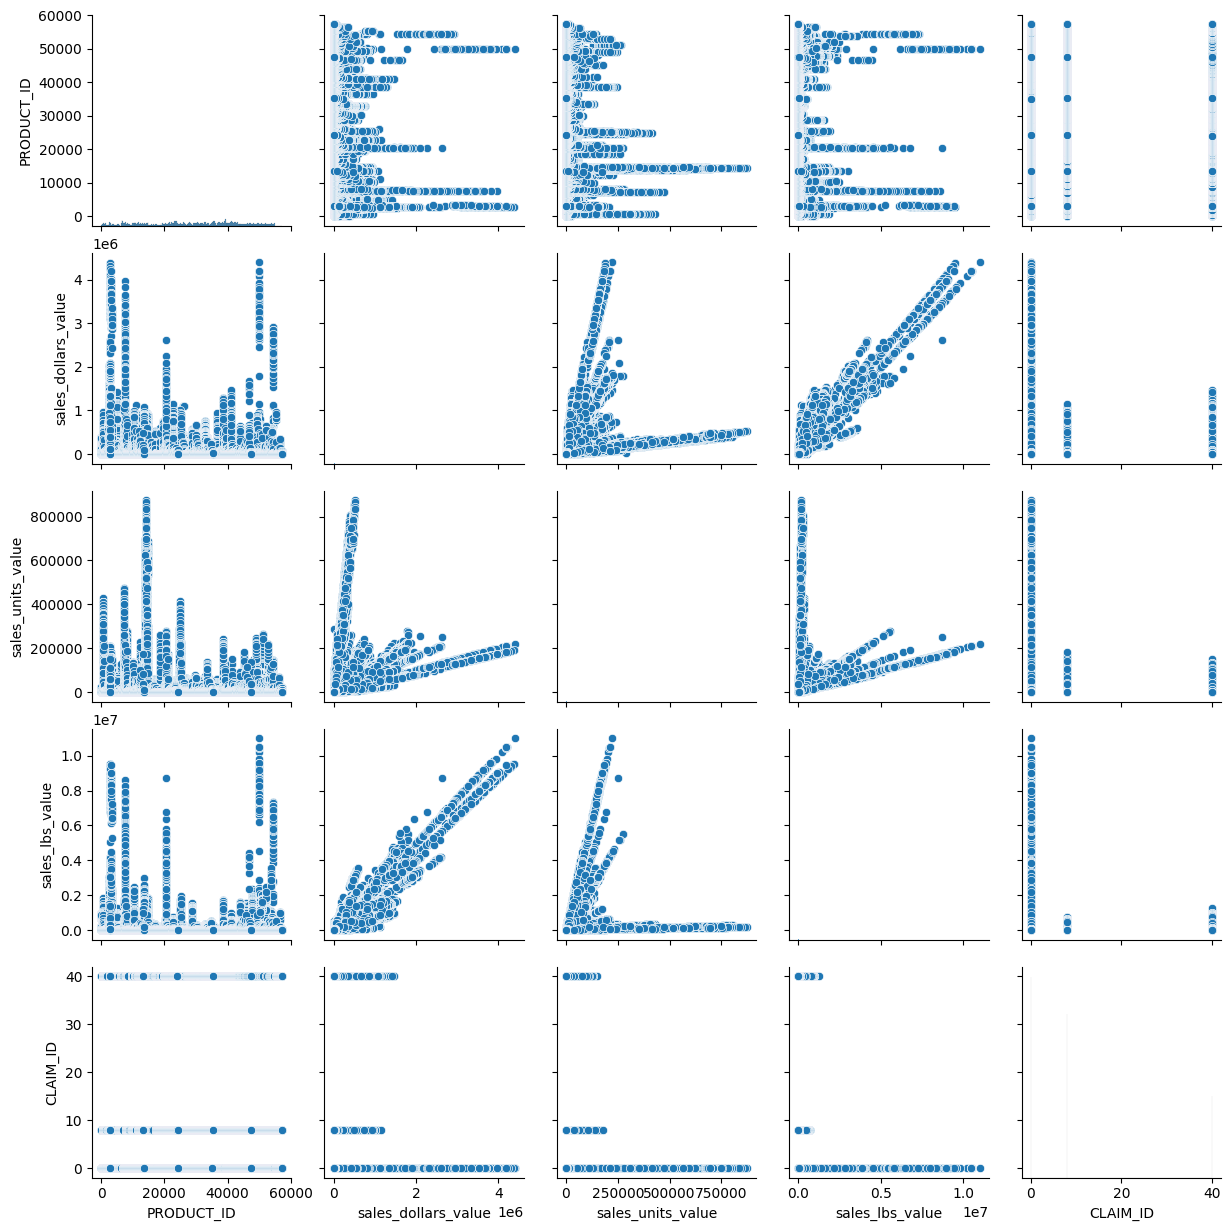

In [101]:
sns.pairplot(base_dataset)

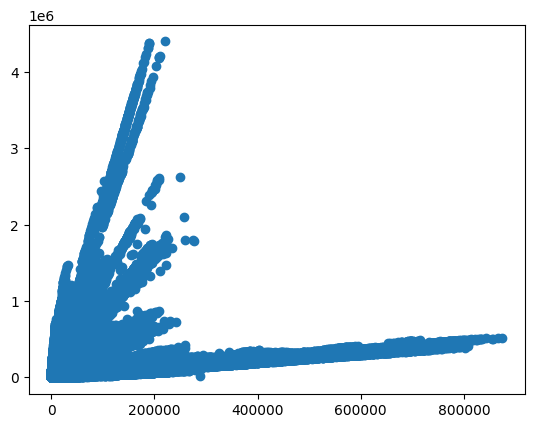

In [102]:
plt.scatter(base_dataset['sales_units_value'],base_dataset['sales_dollars_value'])

In [103]:
cat = [i for i in base_dataset.columns if i not in base_dataset.describe().columns]

In [104]:
cat

['Vendor']

In [105]:
base_dataset['Vendor'].unique()

array(['Others', 'A', 'Private Label', 'B', 'E', 'D', 'F', 'G', 'H'],
      dtype=object)

In [106]:
base_dataset['Vendor'].nunique()

9

In [107]:
from sklearn.preprocessing import LabelEncoder

def label_encoders(data,cat):
  le = LabelEncoder()
  for i in cat:
    le.fit(data[i])
    x = le.transform(data[i])
    data[i] = x
  return data

In [108]:
base_data_label_encoded = label_encoders(base_dataset,cat)

In [109]:
base_data_label_encoded.head(2)

,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID
0,1,13927.0,934,18680,7,0
1,3,10289.0,1592,28646,7,0


In [110]:
base_data_label_encoded.shape

(4540917, 6)

In [111]:
base_data_label_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4540917 entries, 0 to 7767418
Data columns (total 6 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PRODUCT_ID           int64  
 1   sales_dollars_value  float64
 2   sales_units_value    int64  
 3   sales_lbs_value      int64  
 4   Vendor               int64  
 5   CLAIM_ID             int64  
dtypes: float64(1), int64(5)
memory usage: 242.5 MB


In [112]:
x=base_data_label_encoded.drop('sales_dollars_value',axis=1)
y=base_data_label_encoded['sales_dollars_value']

In [113]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [114]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(3632733, 5) (908184, 5) (3632733,) (908184,)


In [115]:
from sklearn.linear_model import LinearRegression
ln=LinearRegression()
ln.fit(X_train,y_train)
ln.predict(X_test)

array([ 8078.62577663, 32891.84088071,  3926.57802091, ...,
       53245.81363858,  8134.7359972 ,  4980.43584185], shape=(908184,))

In [116]:
abs(y_test.values-ln.predict(X_test)).sum()

np.float64(12943171518.187012)

In [117]:
from sklearn.linear_model import Lasso
ls = Lasso()
ls.fit(X_train,y_train)
ls.predict(X_test)

abs(y_test.values - ls.predict(X_test)).sum()

np.float64(12943179932.811762)

In [118]:
from sklearn.linear_model import Ridge
rd = Ridge()
rd.fit(X_train,y_train)
rd.predict(X_test)

abs(y_test.values - rd.predict(X_test)).sum()

np.float64(12943171522.667135)

### Model Validation

In [119]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,r2_score

In [120]:
validation_table = []

for i in[LinearRegression,Lasso,Ridge]:
  rd = i()
  rd.fit(X_train,y_train)
  rd.predict(X_test)

  mae=mean_absolute_error(y_test.values,rd.predict(X_test))
  mse=mean_squared_error(y_test.values,rd.predict(X_test))
  rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
  rsquare=r2_score(y_test.values,rd.predict(X_test))

  validation_table.append([i,mae,mse,rmse,mape,rsquare])

C:\Users\DELL\AppData\Local\Temp\ipykernel_15512\1586512253.py:11: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_15512\1586512253.py:11: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_15512\1586512253.py:11: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])


In [121]:
validation_table = pd.DataFrame(validation_table)

In [122]:
validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]

In [123]:
validation_table

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,14251.706172,1.334215e+09,36526.911924,inf,0.755528
1,<class 'sklearn.linear_model._coordinate_desce...,14251.715437,1.334215e+09,36526.911030,inf,0.755529
2,<class 'sklearn.linear_model._ridge.Ridge'>,14251.706177,1.334215e+09,36526.911923,inf,0.755528


In [124]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor

In [125]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def model_validation(x):

    models = [
        LinearRegression(),
        Lasso(),
        Ridge(),
        DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ),
        RandomForestRegressor(
            n_estimators=20,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        BaggingRegressor(
            n_estimators=10,
            random_state=42
        )
    ]

    validation_table = []

    if x == 'train':

        for rd in models:

            print(f"Training {type(rd).__name__}")

            rd.fit(X_train, y_train)

            y_pred = rd.predict(X_train)

            mae = mean_absolute_error(y_train, y_pred)
            mse = mean_squared_error(y_train, y_pred)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
            rsquare = r2_score(y_train, y_pred)

            validation_table.append([
                type(rd).__name__,
                mae,
                mse,
                rmse,
                mape,
                rsquare
            ])

        validation_table = pd.DataFrame(
            validation_table,
            columns=['modelname', 'mae', 'mse', 'rmse', 'mape', 'rsquare']
        )

        return validation_table

    else:

        for rd in models:

            print(f"Training {type(rd).__name__}")

            rd.fit(X_train, y_train)

            y_pred = rd.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
            rsquare = r2_score(y_test, y_pred)

            validation_table.append([
                type(rd).__name__,
                mae,
                mse,
                rmse,
                mape,
                rsquare
            ])

        validation_table = pd.DataFrame(
            validation_table,
            columns=['modelname', 'mae', 'mse', 'rmse', 'mape', 'rsquare']
        )

        return validation_table

In [126]:
pd.options.display.float_format = '{:0.2f}'.format

In [130]:
model_validation('train')

Training LinearRegression
Training Lasso
Training Ridge
Training DecisionTreeRegressor
Training RandomForestRegressor
Training BaggingRegressor


,modelname,mae,mse,rmse,mape,rsquare
0,LinearRegression,14280.16,1336498588.62,36558.15,inf,0.76
1,Lasso,14280.17,1336498588.81,36558.15,inf,0.76
2,Ridge,14280.16,1336498588.62,36558.15,inf,0.76
3,DecisionTreeRegressor,5859.25,326077613.94,18057.62,inf,0.94
4,RandomForestRegressor,5581.19,279648149.87,16722.68,inf,0.95
5,BaggingRegressor,312.29,2664598.69,1632.36,inf,1.00


In [127]:
model_validation('test')

Training LinearRegression
Training Lasso
Training Ridge
Training DecisionTreeRegressor
Training RandomForestRegressor
Training BaggingRegressor


,modelname,mae,mse,rmse,mape,rsquare
0,LinearRegression,14251.71,1334215294.67,36526.91,inf,0.76
1,Lasso,14251.72,1334215229.43,36526.91,inf,0.76
2,Ridge,14251.71,1334215294.63,36526.91,inf,0.76
3,DecisionTreeRegressor,5878.76,328327088.50,18119.80,inf,0.94
4,RandomForestRegressor,5602.77,282865340.10,16818.60,inf,0.95
5,BaggingRegressor,786.63,14091444.93,3753.86,inf,1.00


In [128]:
print(X_train.shape)
print(X_train.memory_usage(deep=True).sum() / 1024**3, "GB")

(3632733, 5)
0.16239582002162933 GB


R squared Error on test set :  0.6817563567408553
         column_Name  coefficient_value
0         PRODUCT_ID              -0.03
1  sales_units_value               0.55
2    sales_lbs_value               0.47
3             Vendor           -2400.11
4           CLAIM_ID              53.88


<BarContainer object of 5 artists>

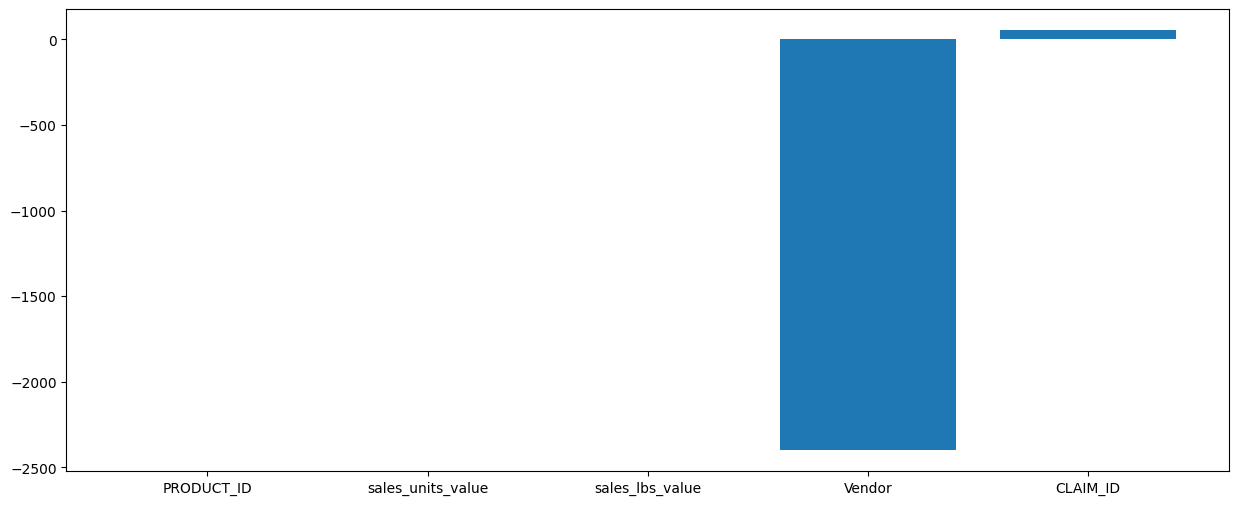

In [132]:
linreg = LinearRegression()
linreg.fit(X_train,y_train)

linreg_prediction = linreg.predict(X_test)

R_squared = r2_score(linreg_prediction,y_test)
print("R squared Error on test set : ", R_squared)


coefficient_df = pd.DataFrame()
coefficient_df['column_Name'] = X_train.columns
coefficient_df['coefficient_value'] = pd.Series(linreg.coef_)
print(coefficient_df.head())

plt.rcParams['figure.figsize'] = (15,6)
plt.bar(coefficient_df['column_Name'],coefficient_df['coefficient_value'])


R squared Error on test set :  0.6817563566297054
         Column_Name  Coefficient_Value
0         PRODUCT_ID              -0.03
1  sales_units_value               0.55
2    sales_lbs_value               0.47
3             Vendor           -2400.11
4           CLAIM_ID              53.88


<BarContainer object of 5 artists>

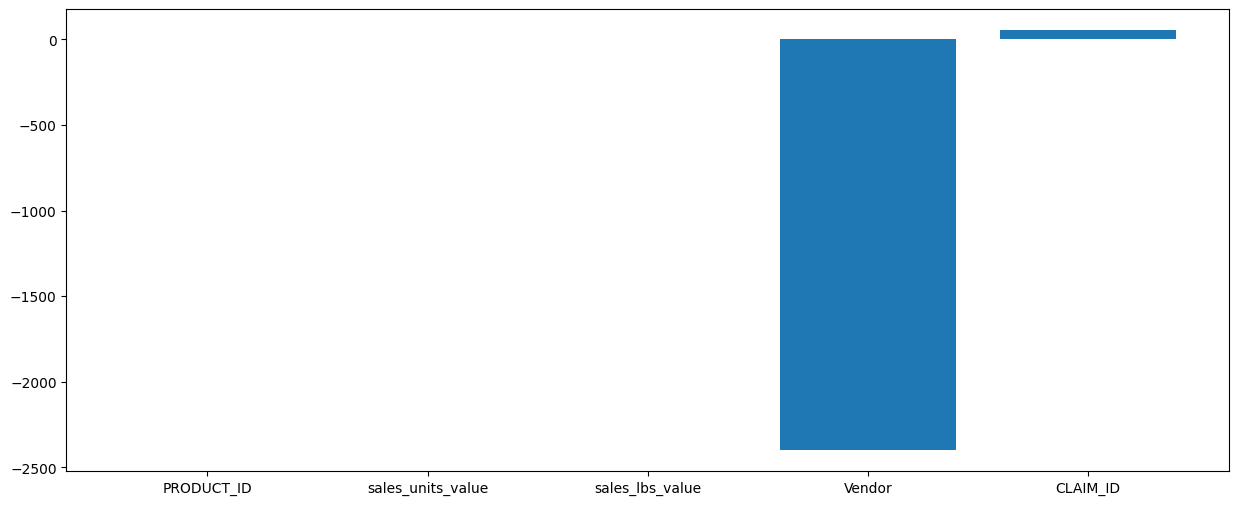

In [133]:
from sklearn.linear_model import Ridge

RidgeRegressor = Ridge(alpha = 0.5)
RidgeRegressor.fit(X_train,y_train)
y_predicted_ridge = RidgeRegressor.predict(X_test)

R_squared = r2_score(y_predicted_ridge,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value'] = pd.Series(RidgeRegressor.coef_)
print(coefficient_df.head(15))

plt.rcParams["figure.figsize"] = (15,6)

plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value"])

R squared Error on test set :  0.6817560103378124
         Column_Name  Coefficient_Value
0         PRODUCT_ID              -0.03
1  sales_units_value               0.55
2    sales_lbs_value               0.47
3             Vendor           -2399.92
4           CLAIM_ID              53.88


<BarContainer object of 5 artists>

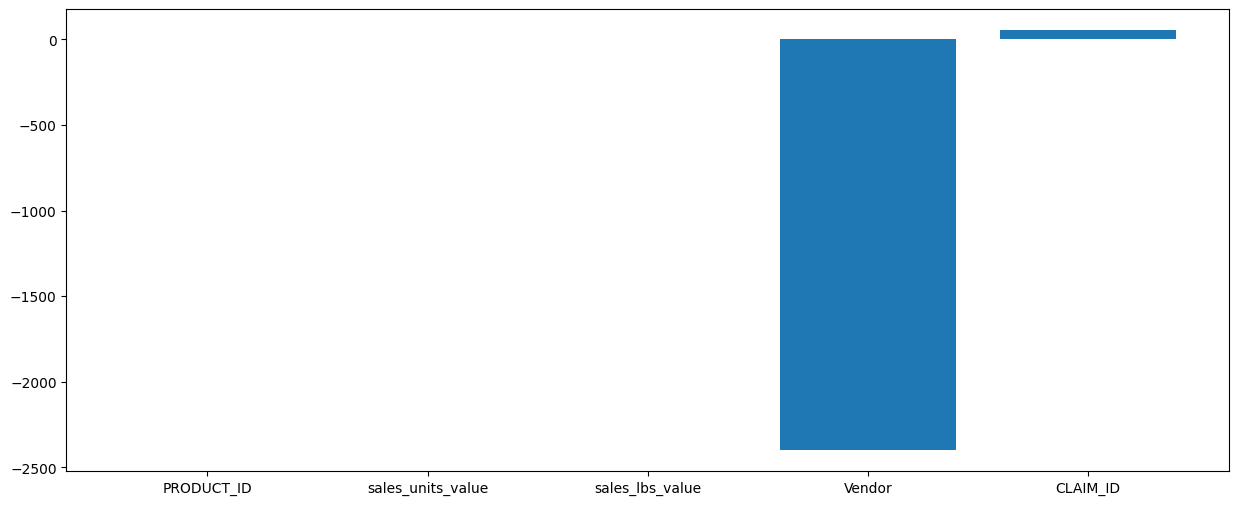

In [134]:
from sklearn.linear_model import Lasso

LassoRegressor = Lasso(alpha = 1)
LassoRegressor.fit(X_train,y_train)
y_predicted_lasso = LassoRegressor.predict(X_test)

R_squared = r2_score(y_predicted_lasso,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value'] = pd.Series(LassoRegressor.coef_)
print(coefficient_df.head(15))

plt.rcParams["figure.figsize"] = (15,6)

plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value"])

In [135]:
#LR with cross validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_regressor = LinearRegression()
mse = cross_val_score(lin_regressor,x,y,scoring = 'neg_mean_squared_error',cv = 5)
mean_mse = np.mean(mse)
print(mean_mse)

-1337283414.186873


### Hyper Parameter Tuning

In [138]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1e-1,5,10,20,30,35,40,50,60,65,100]}

ridge_regressor = GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(x,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1e-15, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [139]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 100}
-1337283413.8355427


In [140]:
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
parameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1e-1,5,10,20,30,35,40,50,60,65,100]}

lasso_regressor = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(x,y)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.377e+15, tolerance: 1.930e+12
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.413e+15, tolerance: 1.978e+12
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

KeyboardInterrupt: 

In [147]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso Model
lasso = Lasso(max_iter=10000)

# Hyperparameter Grid
params = {
    'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

# Grid Search
grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

grid_lasso.fit(X_train_scaled, y_train)

print(grid_lasso.best_params_)
print( grid_lasso.best_score_)

{'alpha': 1}
-1336547772.5055196
